# **EDA - FIFA World Cups Dataset**

This exploratory data analysis focuses on the FIFA World Cups dataset available on Kaggle (credits: Andre Becklas, FIFA World Cup Archive website). 

## **The context**
The FIFA World Cup is a renowned, international soccer competition that is held every four years in a different country. 

## **The dataset**
This dataset consists of three files containing various data on every FIFA World Cup from 1930 to 2014. I chose to center my analysis around the World Cup Matches dataset. It contains the results of all the matches played in every World Cup. 

## **Objectives**
This exploratory data analysis investigates historical FIFA World Cup matches to understand scoring trends evolution, dominant teams, the potential advantage of being the home team and match dynamics between 1930 and 2014. 

## **Importing libraries**

In [1]:
#Importing pandas, numpy, matplotlib and seaborn

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

## **Reading the data**

In [2]:
Matches = pd.read_csv('../input/datasets/abecklas/fifa-world-cup/WorldCupMatches.csv')

## **Data understanding**

In [3]:
Matches.shape

(4572, 20)

The dataset is composed of 4572 rows and 20 columns. Not all columns may be relevant to the analysis. 

In [4]:
# Structure of the dataset

Matches.head(10) 

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA
5,1930.0,16 Jul 1930 - 14:45,Group 1,Parque Central,Montevideo,Chile,3.0,0.0,Mexico,,9249.0,1.0,0.0,CRISTOPHE Henry (BEL),APHESTEGUY Martin (URU),LANGENUS Jean (BEL),201.0,1095.0,CHI,MEX
6,1930.0,17 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,4.0,0.0,Bolivia,,18306.0,0.0,0.0,MATEUCCI Francisco (URU),LOMBARDI Domingo (URU),WARNKEN Alberto (CHI),201.0,1092.0,YUG,BOL
7,1930.0,17 Jul 1930 - 14:45,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Paraguay,,18306.0,2.0,0.0,MACIAS Jose (ARG),APHESTEGUY Martin (URU),TEJADA Anibal (URU),201.0,1097.0,USA,PAR
8,1930.0,18 Jul 1930 - 14:30,Group 3,Estadio Centenario,Montevideo,Uruguay,1.0,0.0,Peru,,57735.0,0.0,0.0,LANGENUS Jean (BEL),BALWAY Thomas (FRA),CRISTOPHE Henry (BEL),201.0,1099.0,URU,PER
9,1930.0,19 Jul 1930 - 12:50,Group 1,Estadio Centenario,Montevideo,Chile,1.0,0.0,France,,2000.0,0.0,0.0,TEJADA Anibal (URU),LOMBARDI Domingo (URU),REGO Gilberto (BRA),201.0,1094.0,CHI,FRA


Indeed, some columns do not seem relevant to answering the questions that will be asked to the data: 'Datetime', 'Stage', 'Stadium', 'City', 'Half-time Home Goals', 'Half-time Away Goals' and all the columns from 'Referee' to 'Away Team Initials'.

The 'Win conditions' column seems to be empty, at least for the first ten rows. This column will be investigated later.  

In [5]:
#Looking for missing values 

Matches.isna()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4567,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4568,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4569,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4570,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [6]:
Matches.isna().sum().sort_values(ascending=False)

Attendance              3722
Year                    3720
Stage                   3720
Datetime                3720
Stadium                 3720
City                    3720
Home Team Goals         3720
Home Team Name          3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64

There is a great amount of missing values in the dataset since 3720 rows out of 4572 contain missing values. 

In [7]:
#Printing the rows that hold missing values

missing_values = Matches.isna().any(axis=1)
Matches[missing_values]

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
823,2014.0,30 Jun 2014 - 17:00,Round of 16,Estadio Beira-Rio,Porto Alegre,Germany,2.0,1.0,Algeria,Germany win after extra time,NaN,0.0,0.0,RICCI Sandro (BRA),DE CARVALHO Emerson (BRA),VAN GASSE Marcelo (BRA),255951.0,300186460.0,GER,ALG
841,2014.0,30 Jun 2014 - 17:00,Round of 16,Estadio Beira-Rio,Porto Alegre,Germany,2.0,1.0,Algeria,Germany win after extra time,NaN,0.0,0.0,RICCI Sandro (BRA),DE CARVALHO Emerson (BRA),VAN GASSE Marcelo (BRA),255951.0,300186460.0,GER,ALG
852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


More than half of the rows contain missing values. Dropping them on the whole dataset would mean holding out most of the data from the analysis. Imputing them using the mean would be biased since the mean would be calculated with only a small fraction of the dataset. Plus, groupbys will be used to analyze the data, meaning that pandas will ignore missing values. Thus, dropping or imputing the missing values doesn't appear to be relevant for this EDA so far. 

Now let's investigate the 'Win Conditions' column, the one that seemed empty.

In [8]:
#Taking a look at the categories the 'Win conditions' column can take

Matches['Win conditions'].unique()

array([' ', 'Austria win after extra time ',
       'Italy win after extra time ', 'Brazil win after extra time ',
       'Czechoslovakia win after extra time ',
       'Hungary win after extra time ',
       'Northern Ireland win after extra time ',
       'England win after extra time ',
       'Germany FR win after extra time ',
       'Uruguay win after extra time ', 'Argentina win after extra time ',
       ' win on penalties (5 - 4) ', 'Belgium win after extra time ',
       'France win on penalties (3 - 4) ',
       'Germany FR win on penalties (4 - 1) ',
       'Belgium win on penalties (4 - 5) ',
       'France win after extra time ', 'Cameroon win after extra time ',
       'Republic of Ireland win on penalties (5 - 4) ',
       'Yugoslavia win after extra time ', ' win on penalties (2 - 3) ',
       ' win on penalties (3 - 4) ', ' win on penalties (4 - 3) ',
       'Bulgaria win on penalties (1 - 3) ',
       'Sweden win on penalties (4 - 5) ',
       'Brazil win on penaltie

In [9]:
Matches['Win conditions'].value_counts() 

Win conditions
                                                 787
Italy win after extra time                         5
Argentina win after extra time                     4
Germany win after extra time                       4
England win after extra time                       3
Belgium win after extra time                       3
Win on Golden Goal                                 3
Brazil win on penalties (3 - 2)                    3
France win after extra time                        2
Costa Rica win on penalties (5 - 3)                2
Argentina win on penalties (2 - 4)                 2
Netherlands win on penalties (4 - 3)               2
France win on penalties (3 - 4)                    2
Hungary win after extra time                       1
Germany FR win after extra time                    1
Czechoslovakia win after extra time                1
Brazil win after extra time                        1
Austria win after extra time                       1
Northern Ireland win after extr

Most of the categories appear only once in the dataset. Moreover, this column doesn't serve the analysis so it probably will not be considered.

In [10]:
#Running basic statistics on the numerical values of the dataset

Matches.describe()

,Year,Home Team Goals,Away Team Goals,Attendance,Half-time Home Goals,Half-time Away Goals,RoundID,MatchID
count,852.000000,852.000000,852.000000,850.000000,852.000000,852.000000,8.520000e+02,8.520000e+02
mean,1985.089202,1.811033,1.022300,45164.800000,0.708920,0.428404,1.066177e+07,6.134687e+07
std,22.448825,1.610255,1.087573,23485.249247,0.937414,0.691252,2.729613e+07,1.110572e+08
min,1930.000000,0.000000,0.000000,2000.000000,0.000000,0.000000,2.010000e+02,2.500000e+01
25%,1970.000000,1.000000,0.000000,30000.000000,0.000000,0.000000,2.620000e+02,1.188750e+03
50%,1990.000000,2.000000,1.000000,41579.500000,0.000000,0.000000,3.370000e+02,2.191000e+03
75%,2002.000000,3.000000,2.000000,61374.500000,1.000000,1.000000,2.497220e+05,4.395006e+07
max,2014.000000,10.000000,7.000000,173850.000000,6.000000,5.000000,9.741060e+07,3.001865e+08


If we take a look at the Home Team Goals and Away Team Goals statistics, we see that, on average, teams listed as home teams seem to score more goals (2-times fold change) than those listed as away teams. So it will be very interesting to see if there is any advantage to being designated as the home team, even though there probably is not. We need to be cautious with the interpretation of the mean since there is a lot of variation in the data. 



## **Creating a subset of the dataset**

As previously discussed, there are many columns in the dataset and some of them are not informative in regard to the analysis that will be conducted on the data. So only a subset of 6 features from the original dataset - considered relevant - will be used: 'Year', 'Attendance', 'Home Team Name', 'Home Team Goals', 'Away Team Name', 'Away Team Goals'.

In [11]:
# Creating the subset

features = ['Year','Attendance', 'Home Team Name','Home Team Goals', 'Away Team Name','Away Team Goals']
Matches_sub = Matches[features]

### **Distribution of the data**

Now let us take a look at the distribution of the number of goals scored for both the home and the away teams throughout the years. 

Text(0.5, 1.0, 'Distribution of the number of goals scored by away teams in the FIFA World Cups (1930-2014)')

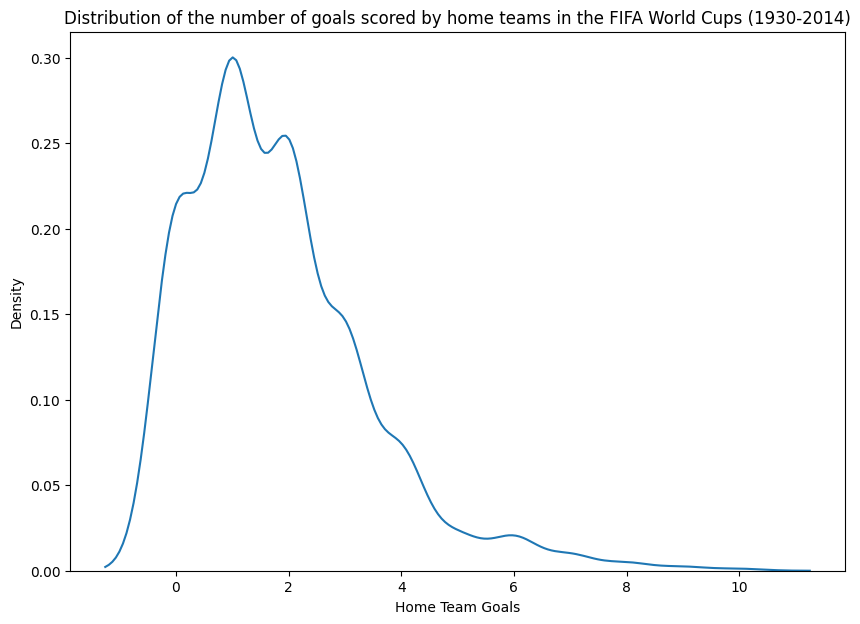

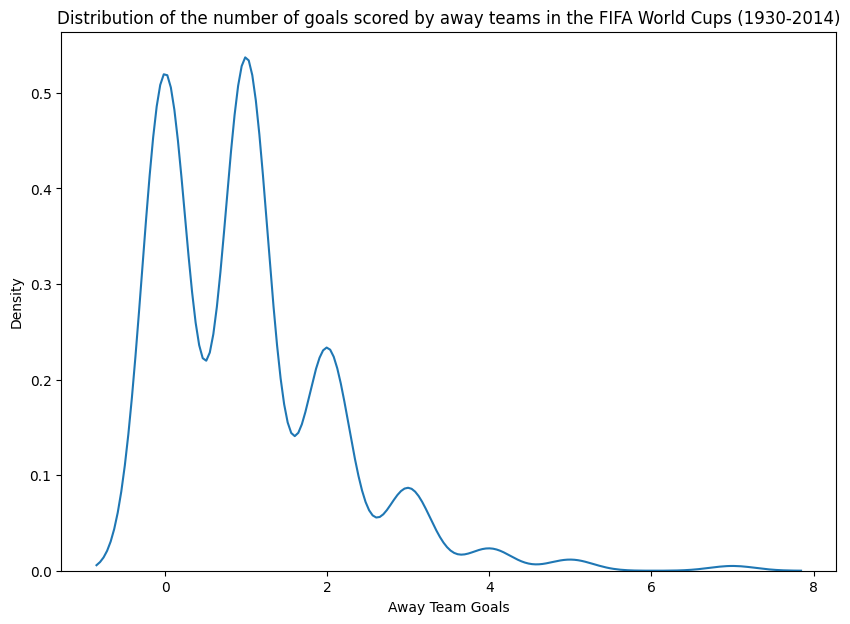

In [12]:
# Home Team Goals

fig, ax = plt.subplots(figsize=(10,7))
sns.kdeplot(data = Matches_sub['Home Team Goals'])
plt.title('Distribution of the number of goals scored by home teams in the FIFA World Cups (1930-2014)')

# Away Team Goals

fig, ax = plt.subplots(figsize=(10,7))
sns.kdeplot(data = Matches_sub['Away Team Goals'])
plt.title('Distribution of the number of goals scored by away teams in the FIFA World Cups (1930-2014)')

For both the home and away teams, most of the data is concentrated between 0 and 3 goals scored per match. 

Let's see how the attendance to matches has evolved between 1930 and 2014. 

Text(0.5, 1.0, 'Trends in FIFA World Cup attendance from 1930 to 2014')

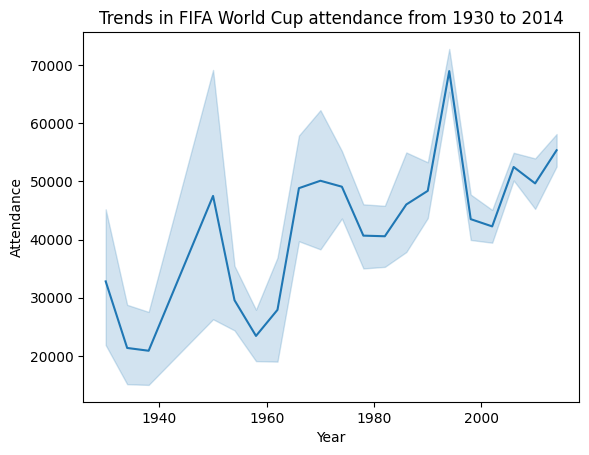

In [13]:
sns.lineplot(x = Matches_sub.Year, y = Matches_sub.Attendance)
plt.title('Trends in FIFA World Cup attendance from 1930 to 2014')

There seems to be an overall increasing tendency in the number of people attending the FIFA World Cup matches with time. It peaks in the 1950s, in the 1970s and in the 1990s. It would be interesting to check if there is any link with the evolution of matches dynamics throughout the years. 

## **Question 1: Which teams won the most matches throughout all World Cups from 1930 to 2014?**

With this question, the top 10 best performing teams throughout all FIFA World Cups will be analyzed.

First, a new column - 'Winner' - is created in the Matches subset. It will report the name of the winning team based on the comparison between the number of goals scored by the home team and by the away team. 

For the question that is investigated here, the missing values become problematic. If any of the Home Team Goals or the Away Team Goals column miss a value, then neither the win_mask nor the no_win_mask conditions (see code cell below) are satisfied. Thus, the rows with missing values in one or both of these column fall into the default case and a strong bias in favor of the away teams is induced. To avoid that, missing values will be dropped from both of these columns.  

In [14]:
#Creating a new column 'Winner' with the name of the team that won the match

#First getting rid of the missing values to avoid inducing any bias in the interpretation of the wins
Matches_sub = Matches_sub.dropna(axis=0, how='any', subset=['Home Team Goals', 'Away Team Goals'])

#Creating a boolean filter to define a win 
win_mask = (Matches_sub['Home Team Goals'] > Matches_sub['Away Team Goals'])
no_win_mask = (Matches_sub['Home Team Goals'] == Matches_sub['Away Team Goals'])

#Creating a column - 'Winner' - with a default value then updating the value
Matches_sub['Winner'] = Matches_sub['Away Team Name']
Matches_sub.loc[no_win_mask, 'Winner'] = 'No Winner'
Matches_sub.loc[win_mask, 'Winner'] = Matches_sub['Home Team Name']

In [15]:
# Checking out the update of the dataset part 1

Matches_sub.head()

,Year,Attendance,Home Team Name,Home Team Goals,Away Team Name,Away Team Goals,Winner
0,1930.0,4444.0,France,4.0,Mexico,1.0,France
1,1930.0,18346.0,USA,3.0,Belgium,0.0,USA
2,1930.0,24059.0,Yugoslavia,2.0,Brazil,1.0,Yugoslavia
3,1930.0,2549.0,Romania,3.0,Peru,1.0,Romania
4,1930.0,23409.0,Argentina,1.0,France,0.0,Argentina


In [16]:
# Checking out the update of the dataset part 2

Matches_sub['Winner'].value_counts()

Winner
No Winner                     190
Brazil                         71
Italy                          45
Argentina                      44
Germany FR                     36
                             ... 
Jamaica                         1
Slovenia                        1
Serbia                          1
Slovakia                        1
rn">Bosnia and Herzegovina      1
Name: count, Length: 65, dtype: int64

Now let us see which teams performed best during the FIFA World Cups from 1930 to 2014. 

Text(0.5, 1.0, 'Top 10 best performing teams in FIFA World Cups (1930-2014)')

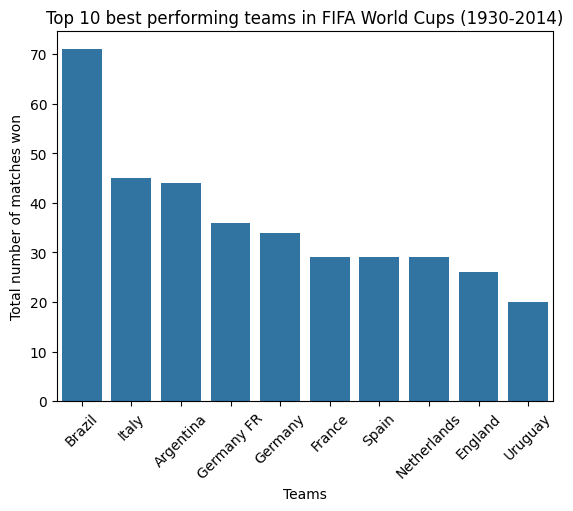

In [17]:
# Top 10 best performing countries

#Creating a boolean filter to get rid of the 'No Winner' value (since it does not correspond to any actual country)
drop_no_winner = Matches_sub['Winner'] != 'No Winner'

#Counting the number of wins per country
win_per_country = Matches_sub[drop_no_winner].groupby('Winner').size().sort_values(ascending=False).head(10) 

#Plotting the result 
sns.barplot(x = win_per_country.index, y = win_per_country.values)
plt.xticks(rotation = 45)
plt.xlabel('Teams')
plt.ylabel('Total number of matches won')
plt.title('Top 10 best performing teams in FIFA World Cups (1930-2014)')

Brazil is by far the best performing team, winning 70 matches total throughout all 21 FIFA World Cups held between 1930 and 2014. It is followed by Italy, Argentina and Germany. 

## **Question 2: Do home teams win more often?**

In this dataset, the "home team" does not represent a real home advantage since World Cup matches are played in neutral venues. The designation simply reflects the team listed first in the match record. 

Through comparing the number of goals scored when teams are listed first to the number of goals they score when they are not, the potential advantage with being the "home team" will be assessed. 

Here, the missing values would also have been an issue for the same reason that was mentioned above: a bias would be induced. Since they have already been taken care of in the previous question, we can directly use the updated Matches subset (with rhe missing values dropped). 

In [18]:
#Home wins and away wins

#Reusing the boolean filter previously created to get rid of the 'No Winner' values
drop_no_winner = Matches_sub['Winner'] != 'No Winner'
Matches_sub_without_draws = Matches_sub[drop_no_winner]

#Creating a boolean filter to make the analysis on the top 10 best performing countries only
top_10 = Matches_sub['Winner'].isin(win_per_country.index)

#Defining two new columns in the Matches subset, home_win and away_win
Matches_sub_without_draws['home_win'] = (Matches_sub['Winner'] == Matches_sub['Home Team Name'])
Matches_sub_without_draws['away_win'] = (Matches_sub['Winner'] == Matches_sub['Away Team Name'])

#Summing up the number of home wins and away wins throughout all World Cups for each team of the top 10
wins_location = Matches_sub_without_draws[top_10].groupby('Winner')[['home_win', 'away_win']].sum().sort_values(by = ['home_win'], ascending=False)
wins_location

/tmp/ipykernel_15/1890829886.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Matches_sub_without_draws['home_win'] = (Matches_sub['Winner'] == Matches_sub['Home Team Name'])
/tmp/ipykernel_15/1890829886.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Matches_sub_without_draws['away_win'] = (Matches_sub['Winner'] == Matches_sub['Away Team Name'])
/tmp/ipykernel_15/1890829886.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  wins_location = Matches_sub_without_draw

,home_win,away_win
Winner,,
Brazil,59,12
Argentina,41,3
Italy,38,7
Germany FR,29,7
Germany,24,10
England,22,4
France,19,10
Netherlands,18,11
Spain,16,13


In [19]:
#Average number of wins for the home teams

Matches_sub_without_draws['home_win'].mean()

np.float64(0.7371601208459214)

73% of the matches without draws throughout all World Cups were won by the team listed as "home team". This at least applies to the top 10 best performing team. There seems to be a bias here. It could be explained by the fact that the home team - the team that's listed first - is usually the best one. This result suggests that there might be a construction/structure bias in the dataset or an asymetry in the way teams are ranked/classified.

In [20]:
print(Matches_sub_without_draws.groupby('Home Team Name')['Home Team Goals'].mean())
Matches_sub_without_draws.groupby('Away Team Name')['Away Team Goals'].mean()

Home Team Name
Algeria                       0.750000
Angola                        0.000000
Argentina                     2.163265
Australia                     1.400000
Austria                       2.416667
                                ...   
Yugoslavia                    2.928571
Zaire                         0.000000
rn">Bosnia and Herzegovina    3.000000
rn">Serbia and Montenegro     0.000000
rn">United Arab Emirates      0.000000
Name: Home Team Goals, Length: 73, dtype: float64


Away Team Name
Algeria                       1.285714
Argentina                     1.058824
Australia                     0.200000
Austria                       0.615385
Belgium                       0.894737
                                ...   
rn">Bosnia and Herzegovina    0.500000
rn">Republic of Ireland       1.000000
rn">Serbia and Montenegro     1.000000
rn">Trinidad and Tobago       0.000000
rn">United Arab Emirates      1.000000
Name: Away Team Goals, Length: 82, dtype: float64

The number of wins depends on the total number of matches played by each team. To normalize the result, both the number of home and away wins are divided by the total number of wins per team. By doing so, we get ratios that are easier to compare between teams.

In [21]:
#Calculating proportions 

wins_location['total_wins'] = wins_location['away_win'] + wins_location['home_win']
wins_location['home_ratio'] = wins_location['home_win']/wins_location['total_wins']
wins_location['away_ratio'] = wins_location['away_win']/wins_location['total_wins']
wins_location = wins_location.sort_values(by = ['total_wins'], ascending = False)
wins_location

,home_win,away_win,total_wins,home_ratio,away_ratio
Winner,,,,,
Brazil,59,12,71,0.830986,0.169014
Italy,38,7,45,0.844444,0.155556
Argentina,41,3,44,0.931818,0.068182
Germany FR,29,7,36,0.805556,0.194444
Germany,24,10,34,0.705882,0.294118
France,19,10,29,0.655172,0.344828
Spain,16,13,29,0.551724,0.448276
Netherlands,18,11,29,0.620690,0.379310
England,22,4,26,0.846154,0.153846


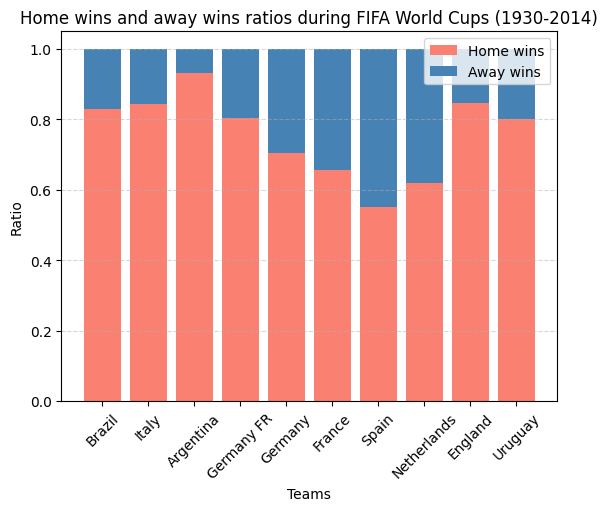

In [22]:
#Plotting the result (stacked barplot)

plt.bar(wins_location.index, wins_location['home_ratio'], color = 'salmon')
plt.bar(wins_location.index, wins_location['away_ratio'], bottom = wins_location['home_ratio'], color = 'steelblue')
plt.xticks(rotation = 45)
plt.xlabel('Teams')
plt.ylabel('Ratio')
plt.legend(['Home wins', 'Away wins'])
plt.title('Home wins and away wins ratios during FIFA World Cups (1930-2014)')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

All ten best performing teams won the most when they were listed as "home team". So there seems to be a slight advantage associated with being the home team. 
However, this designation does not represent a real advantage since World Cup matches are played at neutral venues. Again, it is not an expected result and there might be a bias in the structure of the dataset or the way teams were classified. It would be interesting to calculate the average number of home wins for all teams throughout all World Cups.  

## **Question 3: Which teams are the most dominant?**

The designation "dominant" for a team means having scored a great amount of goals throughout all World Cups.

In [23]:
#Calculating the total number of wins per team

total_goals_home = Matches_sub.groupby('Home Team Name')['Home Team Goals'].sum()
total_goals_away = Matches_sub.groupby('Away Team Name')['Away Team Goals'].sum()
total_goals_perteam = total_goals_home.add(total_goals_away, fill_value=0).sort_values(ascending = False).head(10)
total_goals_perteam

Brazil         225.0
Argentina      133.0
Germany FR     131.0
Italy          128.0
France         108.0
Germany        104.0
Spain           92.0
Netherlands     91.0
Hungary         87.0
Uruguay         80.0
dtype: float64

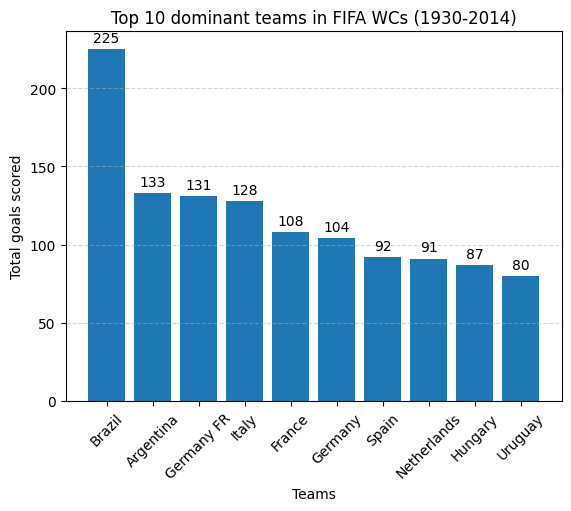

In [24]:
#Plotting the result

bars = plt.bar(total_goals_perteam.index, total_goals_perteam.values)
plt.bar_label(bars, padding = 3) # adding annotations to the plot (paddind => space between the annotation and the bar)
plt.xticks(rotation = 45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.xlabel('Teams')
plt.ylabel('Total goals scored')
plt.title('Top 10 dominant teams in FIFA WCs (1930-2014)')
plt.show()

Brazil is by far the most dominant team throughout all World Cups held from 1930 to 2014, scoring 2 to 3 times as much goals as other teams from the top 10. 

## **Question 4: How have World Cup matches dynamic evolved with time?**

The evolution of matches dynamics will be assessed through the evolution of the number of total goals scored for a given World Cup year.

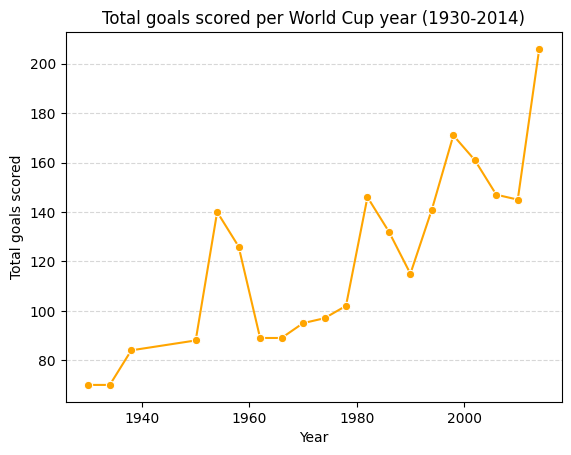

In [25]:
#Total goals per World Cup year

Matches.head(10) # one year (one row) => one match
Matches_sub.head(10)
wins_location.head(10)

#Creating a column with the total number of goals scored per match
Matches_sub['Total goals scored'] = Matches_sub['Home Team Goals'] + Matches_sub['Away Team Goals']

#For a given World Cup year, summing up the number of goals that were scored
total_goals_peryear = Matches_sub.groupby('Year')['Total goals scored'].sum()
total_goals_peryear

#Calculating the average number of goals scored per World Cup year
avg_goals_peryear = total_goals_peryear.mean()
avg_goals_peryear

#Plotting the result
sns.lineplot(data = total_goals_peryear, color = 'orange', marker = 'o')
plt.ylabel('Total goals scored')
plt.title('Total goals scored per World Cup year (1930-2014)')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

There seems to be an overall increasing tendency in the total number of goals scored per World Cup year. There is a peak in the 1950s-1960s, in the 1990s and in the early 2000s, suggesting that these are periods of time where matches became more offensive. It is hard to firmly conclude since the total number of goals scored for a given World Cup year strongly depends on the total number of matches that were held that year. To better asses the evolution of matches dynamics and offensiveness, a normalization needs to be done to get a more accurrate interpretation out of the data.

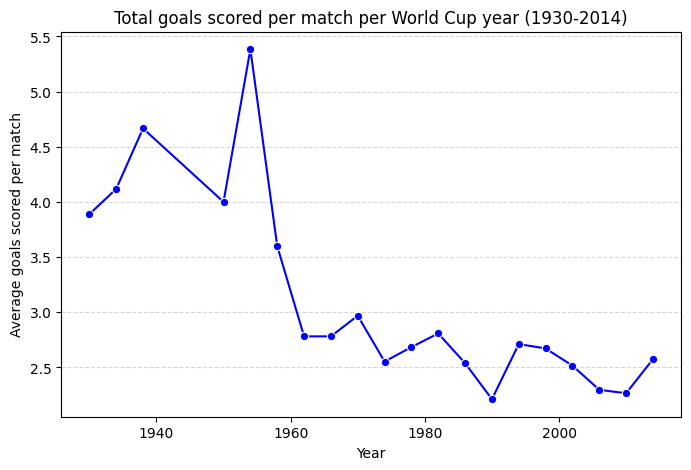

In [26]:
#Total goals per match per World Cup year

#Total number of matches held per World Cup year 
no_of_matches_peryear = Matches_sub.groupby('Year').size()

#Normalizing the total number of goals scored per year by the number of matches that were held that year
avg_goals_permatch = total_goals_peryear / no_of_matches_peryear
avg_goals_permatch

#Plotting the result
plt.figure(figsize = (8,5)) # creating a new figure so that the 2 curves don't share the same plot (scale issue otherwise)
sns.lineplot(data = avg_goals_permatch, color = 'blue', marker = 'o')
plt.ylabel('Average goals scored per match')
plt.title('Total goals scored per match per World Cup year (1930-2014)')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

Interestingly, the total number of goals scored per match per World Cup year seems to be decreasing between the 1930s and the early 2000s before stabilizing. It peaks in the 1950s, in the 1970s and in the 1990s, which is coherent with the previous graph. These data altogether suggest that, overall, FIFA World Cup matches evolved from being very offensive from the 1930s to the 1960s to being more less offensive between the 1960s and the 2000s. It would be very interesting to see if this pattern has any link with the evolution of soccer teams defense strategies with time. 

# **Conclusion and perspectives**

Altogether, the results suggest that Brazil was the best performing team in FIFA World Cups between 1930 and 2014, scorring more goals and winning more matches than other teams. There also seems to be an advantage to being the "home team" that could be explained by a bias in the way the dataset was built or in the way the teams were ranked. Surprisingly, as the total number of goals scored each World Cup year increased throughout the years, the dynamic of the matches became less offensive. 

An interesting perspective would be to investigate the evolution of playing strategies between 1930 and 2014. It could be of help to better understand the dataset that was analyzed in this work. 